In [ ]:
import pandas as pd

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.info()
df.head()
df.describe(include='all')

In [ ]:
df.isnull().sum()

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df = df.dropna(subset=['Sleep Duration', 'Quality of Sleep'])

KeyError: 'Sleep Disorder'

In [ ]:
df['Gender'] = df['Gender'].str.title().str.strip()
df['Occupation'] = df['Occupation'].str.strip()

# Encode
df = pd.get_dummies(df, columns=['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder'], drop_first=True)

In [ ]:
# Split into systolic and diastolic
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = df['Systolic'].astype(float)
df['Diastolic'] = df['Diastolic'].astype(float)
df.drop('Blood Pressure', axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
print( df.duplicated().sum())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df[numeric_cols].hist(figsize=(12, 8), bins=15)
plt.suptitle("Distribution of Numeric Features", fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='Gender_Male', data=df)
plt.title("Gender Distribution (1=Male, 0=Female)")
plt.show()

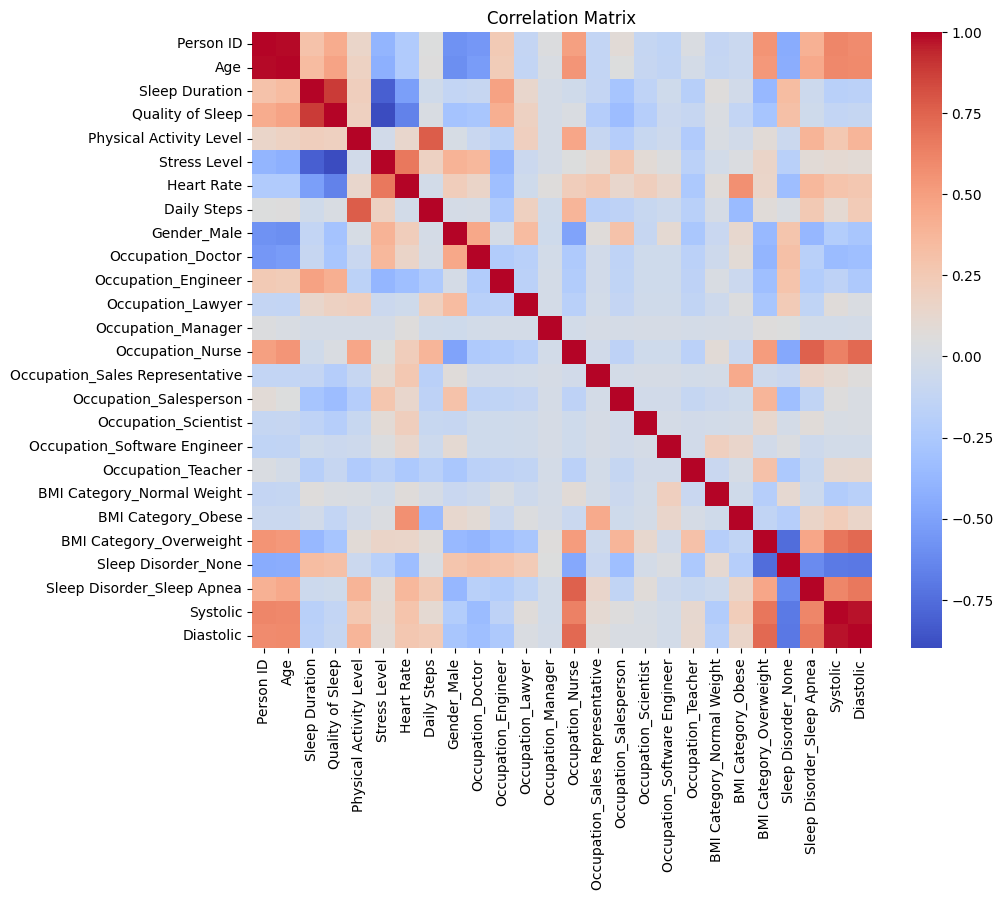

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
sns.pairplot(df[['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Physical Activity Level']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

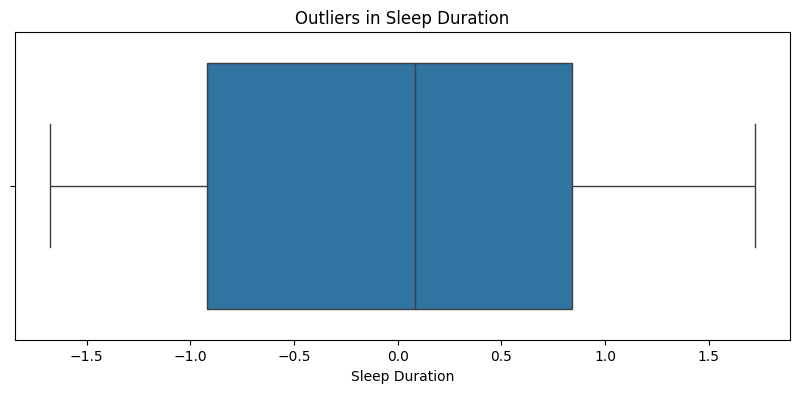

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Sleep Duration'])
plt.title("Outliers in Sleep Duration")
plt.show()

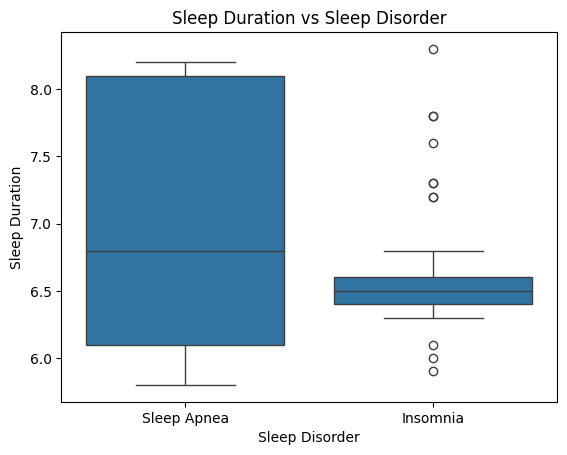

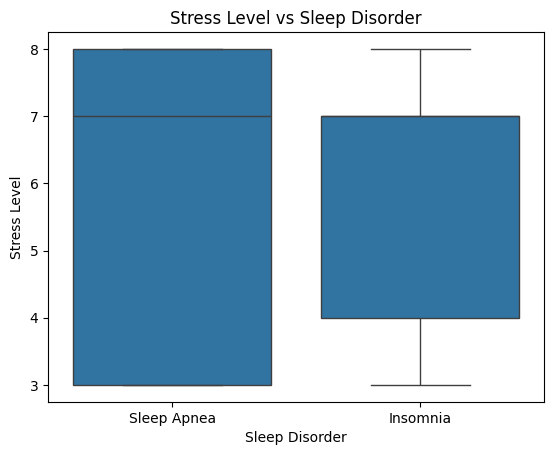

In [ ]:
raw_df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

sns.boxplot(x='Sleep Disorder', y='Sleep Duration', data=raw_df)
plt.title("Sleep Duration vs Sleep Disorder")
plt.show()

sns.boxplot(x='Sleep Disorder', y='Stress Level', data=raw_df)
plt.title("Stress Level vs Sleep Disorder")
plt.show()

In [ ]:
avg_sleep = raw_df.groupby('Occupation')['Sleep Duration'].mean().sort_values()
print("\nAverage Sleep Duration by Occupation:")
print(avg_sleep)


Average Sleep Duration by Occupation:
Occupation
Sales Representative    5.900000
Scientist               6.000000
Salesperson             6.403125
Teacher                 6.690000
Software Engineer       6.750000
Manager                 6.900000
Doctor                  6.970423
Nurse                   7.063014
Accountant              7.113514
Lawyer                  7.410638
Engineer                7.987302
Name: Sleep Duration, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [ ]:
# Sleep Efficiency
df['time_in_bed'] = df['Sleep Duration'] + (df['Daily Steps'] / 5000)
df['sleep_efficiency'] = (df['Sleep Duration'] / df['time_in_bed']) * 100

# HRV Approximation
df['stress_adj'] = 1 - (df['Stress Level'] / 20)
df['hrv_index'] = (60 / df['Heart Rate']) * df['stress_adj']

# Fatigue Index
df['fatigue_index'] = (
    (df['Stress Level'] * 0.4) +
    (df['Heart Rate'] * 0.2) -
    (df['Sleep Duration'] * 0.3) +
    ((df['Daily Steps'] / 10000) * 0.1)
)


In [ ]:
# ✅ Sleep Efficiency (Scientific)
df['time_in_bed'] = df['Sleep Duration'] + (df['Daily Steps'] / 5000)
df['Sleep_Efficiency'] = (df['Sleep Duration'] / df['time_in_bed']) * 100

# ✅ HRV Approximation
df['HRV_Index'] = (60 / df['Heart Rate']) * (1 - df['Stress Level'] / 20)

# ✅ Fatigue Index
df['Fatigue_Index'] = (
    (df['Stress Level'] * 0.4) +
    (df['Heart Rate'] * 0.2) -
    (df['Sleep Duration'] * 0.3) +
    ((df['Daily Steps'] / 10000) * 0.1)
)


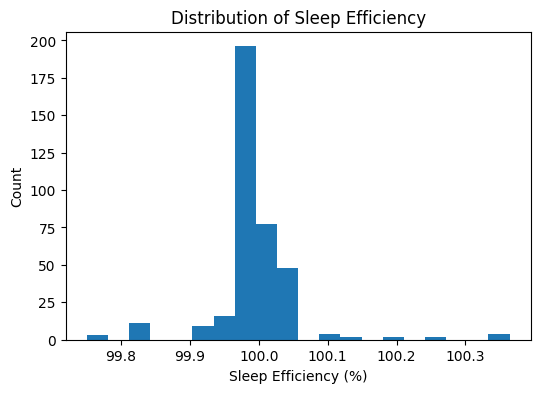

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Sleep_Efficiency'], bins=20)
plt.title("Distribution of Sleep Efficiency")
plt.xlabel("Sleep Efficiency (%)")
plt.ylabel("Count")
plt.show()


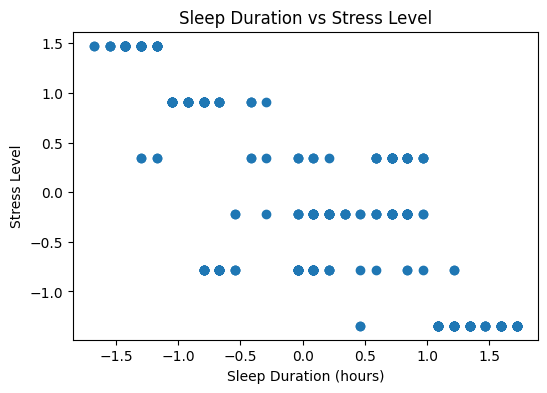

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['Sleep Duration'], df['Stress Level'])
plt.title("Sleep Duration vs Stress Level")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Stress Level")
plt.show()


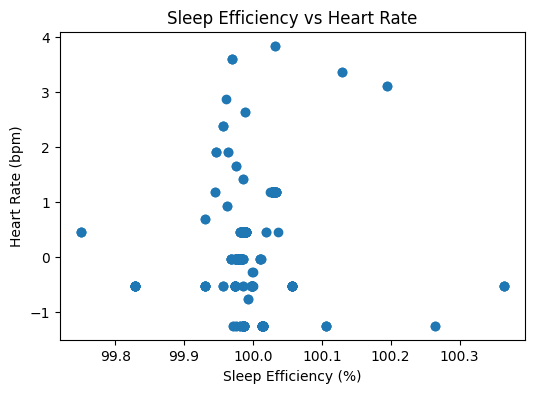

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['Sleep_Efficiency'], df['Heart Rate'])
plt.title("Sleep Efficiency vs Heart Rate")
plt.xlabel("Sleep Efficiency (%)")
plt.ylabel("Heart Rate (bpm)")
plt.show()


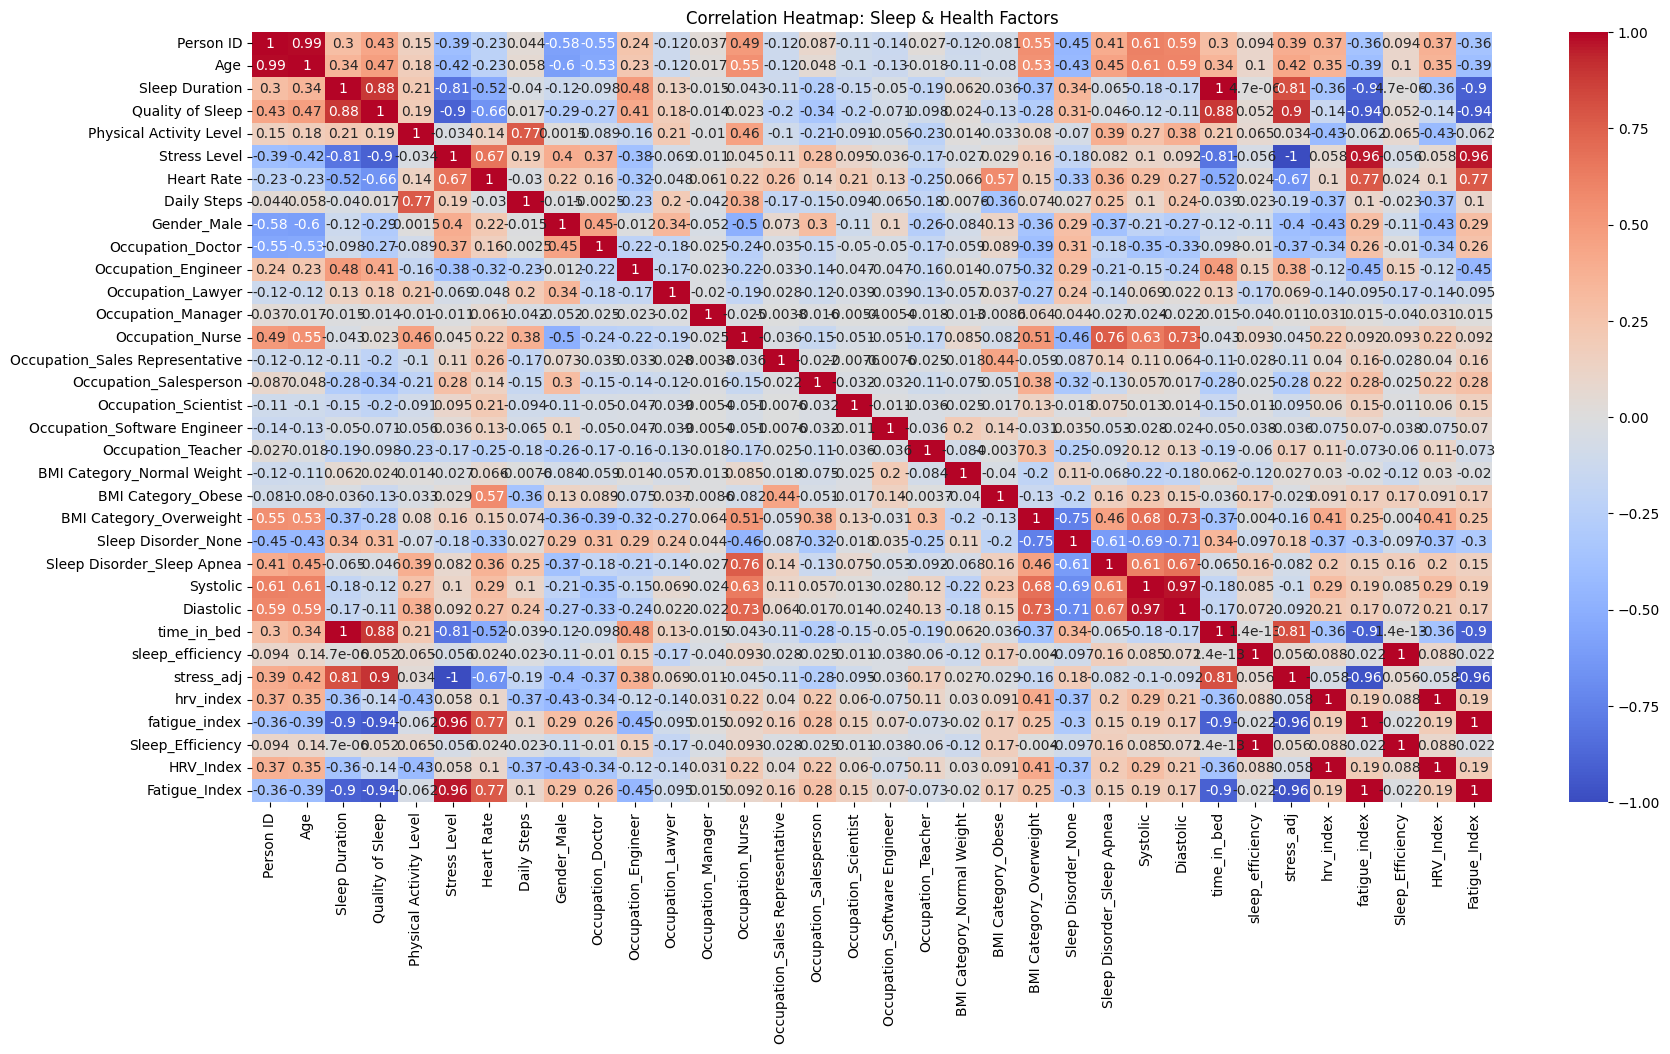

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Sleep & Health Factors")
plt.show()


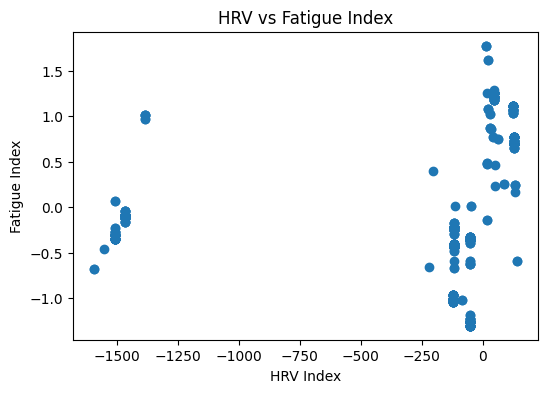

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['HRV_Index'], df['Fatigue_Index'])
plt.title("HRV vs Fatigue Index")
plt.xlabel("HRV Index")
plt.ylabel("Fatigue Index")
plt.show()


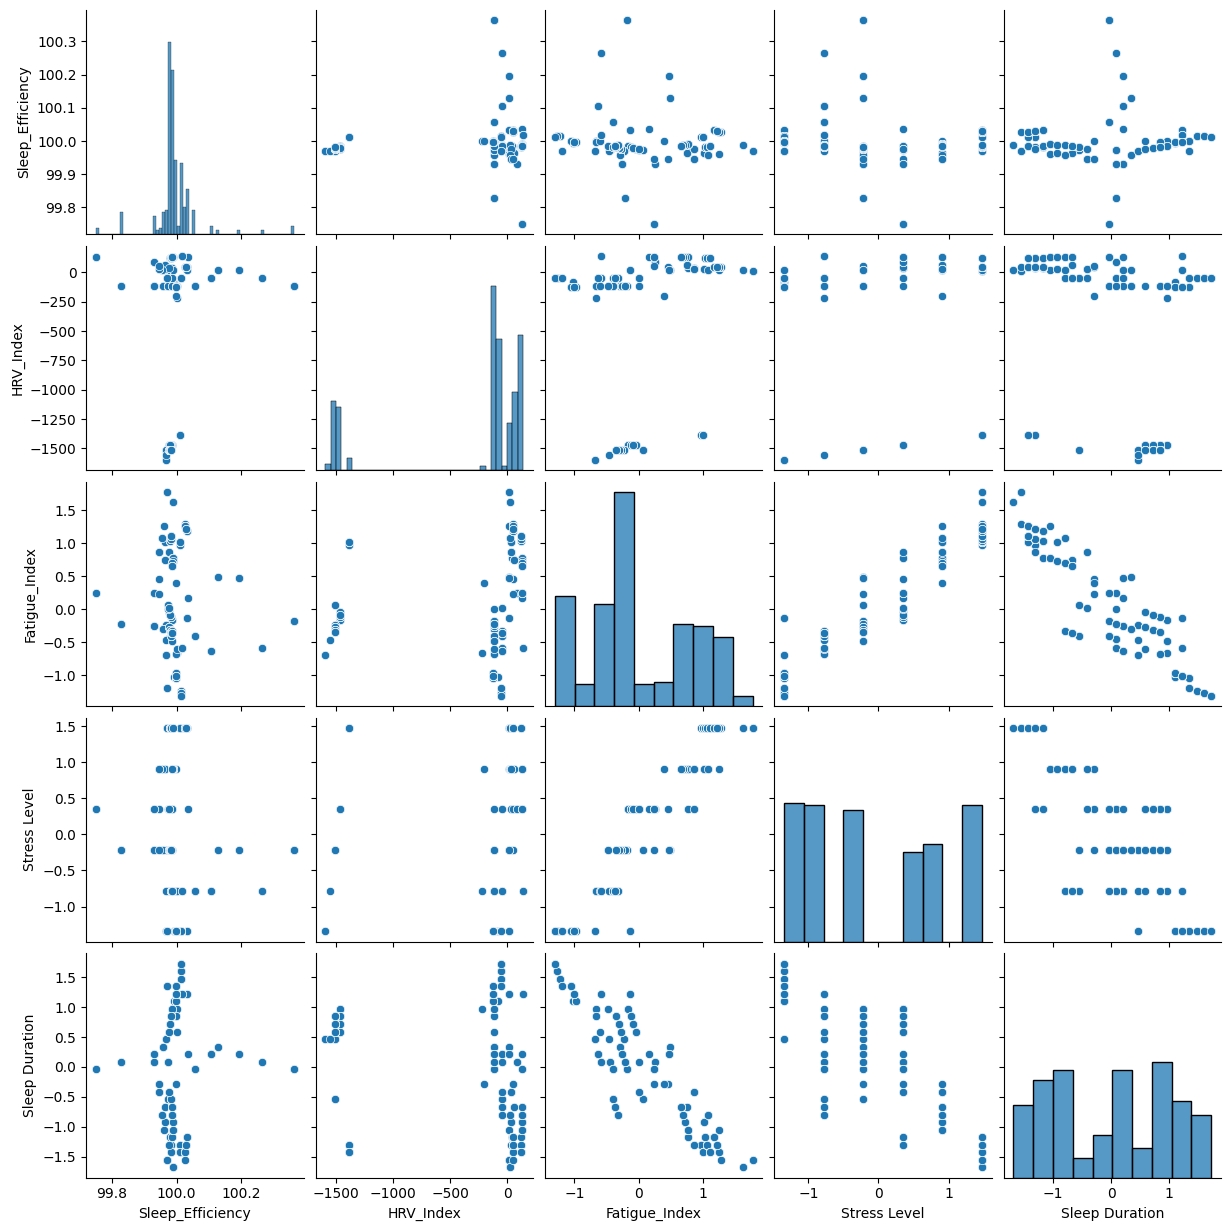

In [ ]:
sns.pairplot(df[['Sleep_Efficiency', 'HRV_Index', 'Fatigue_Index', 'Stress Level', 'Sleep Duration']])
plt.show()


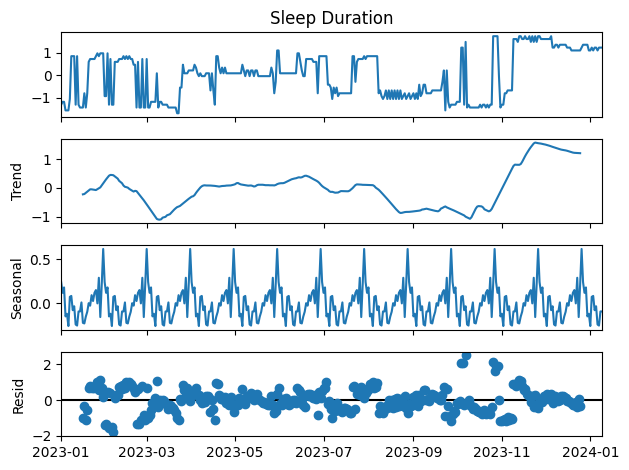

ADF Statistic: -4.43401358025566
p-value: 0.00025828508394992554

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1286  , p=0.7200  , df_denom=370, df_num=1
ssr based chi2 test:   chi2=0.1297  , p=0.7188  , df=1
likelihood ratio test: chi2=0.1297  , p=0.7188  , df=1
parameter F test:         F=0.1286  , p=0.7200  , df_denom=370, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7515  , p=0.4724  , df_denom=367, df_num=2
ssr based chi2 test:   chi2=1.5235  , p=0.4669  , df=2
likelihood ratio test: chi2=1.5204  , p=0.4676  , df=2
parameter F test:         F=0.7515  , p=0.4724  , df_denom=367, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9866  , p=0.3991  , df_denom=364, df_num=3
ssr based chi2 test:   chi2=3.0168  , p=0.3890  , df=3
likelihood ratio test: chi2=3.0046  , p=0.3909  , df=3
parameter F test:         F=0.9866  , p=0.3991  , df_denom=364, df_num=3


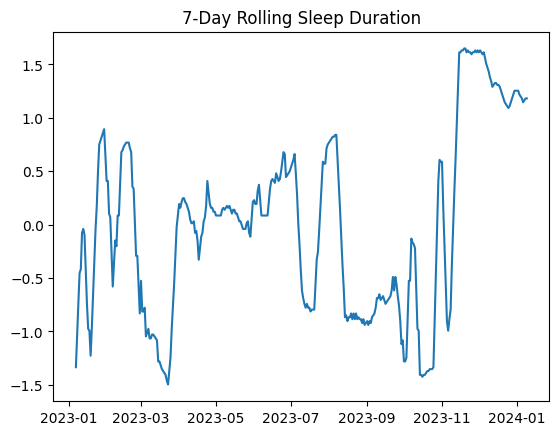

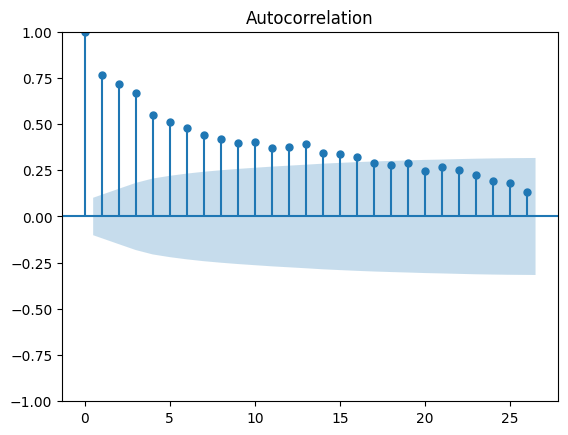

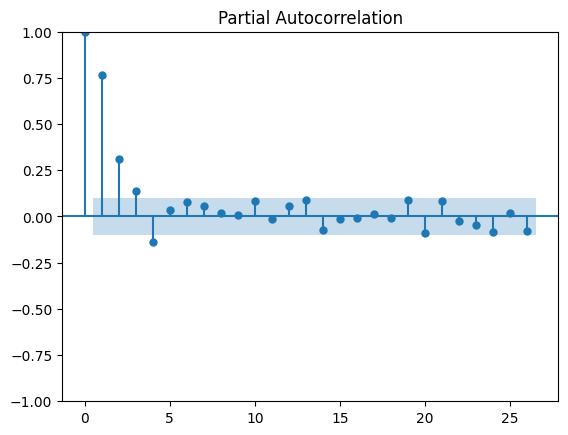

In [ ]:
df['Date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')
df.set_index('Date', inplace=True)
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df['Sleep Duration']

result = seasonal_decompose(ts, model='additive', period=30)
result.plot()
plt.show()
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Sleep Duration'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
df['Sleep_Diff'] = df['Sleep Duration'].diff()
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(df[['Sleep Duration', 'Stress Level']], maxlag=3)
df['sleep_rolling'] = df['Sleep Duration'].rolling(window=7).mean()
df['stress_rolling'] = df['Stress Level'].rolling(window=7).mean()

plt.plot(df['sleep_rolling'])
plt.title("7-Day Rolling Sleep Duration")
plt.show()
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Sleep Duration'])
plt.show()

plot_pacf(df['Sleep Duration'])
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Features for lifestyle/sleep profiles (no labels needed)
cluster_feats = [
    'Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level',
    'Heart Rate','Daily Steps','Systolic','Diastolic',
    'Sleep_Efficiency','HRV_Index','Fatigue_Index'
]

Xc = df[cluster_feats].copy()

# 2) Scale
scaler_c = StandardScaler()
Xc_scaled = scaler_c.fit_transform(Xc)

# 3) Pick k via elbow + silhouette (quick)
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(Xc_scaled)
    inertias.append(km.inertia_)
# (Optionally plot inertias)

# 4) Train final model (choose k=3 as a sensible start)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(Xc_scaled)

df['Sleep_Profile'] = clusters

# 5) Quick profile summary
cluster_summary = df.groupby('Sleep_Profile')[cluster_feats].mean().round(2)
print(cluster_summary)
print("Silhouette:", silhouette_score(Xc_scaled, clusters))


               Sleep Duration  Quality of Sleep  Physical Activity Level  \
Sleep_Profile                                                              
0                        0.60              0.62                     0.19   
1                       -1.33             -1.10                     1.40   
2                       -0.96             -1.09                    -0.92   

               Stress Level  Heart Rate  Daily Steps  Systolic  Diastolic  \
Sleep_Profile                                                               
0                     -0.63       -0.52         0.08     -0.20      -0.16   
1                      1.48        1.17         1.97      1.37       1.54   
2                      1.00        0.84        -0.85      0.01      -0.14   

               Sleep_Efficiency  HRV_Index  Fatigue_Index  
Sleep_Profile                                              
0                         99.99    -497.38          -0.54  
1                        100.03      47.48           

In [ ]:
print(df.columns.tolist())


['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight', 'Sleep Disorder_None', 'Sleep Disorder_Sleep Apnea', 'Systolic', 'Diastolic', 'time_in_bed', 'sleep_efficiency', 'stress_adj', 'hrv_index', 'fatigue_index', 'Sleep_Efficiency', 'HRV_Index', 'Fatigue_Index', 'Sleep_Diff', 'sleep_rolling', 'stress_rolling', 'Sleep_Profile']


In [ ]:
df['Sleep_Disorder_Label'] = df[[
    'Sleep Disorder_None',
    'Sleep Disorder_Sleep Apnea'
]].idxmax(axis=1).str.replace('Sleep Disorder_', '')


In [ ]:
y = df['Sleep_Disorder_Label']

X = df.drop(columns=[
    'Sleep Disorder_None',
    'Sleep Disorder_Sleep Apnea',
    'Sleep_Disorder_Label'
], errors='ignore')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
model = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

        None       0.95      0.92      0.93        59
 Sleep Apnea       0.72      0.81      0.76        16

    accuracy                           0.89        75
   macro avg       0.83      0.86      0.85        75
weighted avg       0.90      0.89      0.90        75


Confusion Matrix:
 [[54  5]
 [ 3 13]]


In [ ]:
importances = model.feature_importances_
feature_names = X.columns

imp = sorted(list(zip(feature_names, importances)),
             key=lambda x: x[1],
             reverse=True)

for name, score in imp[:15]:
    print(name, "=", round(score, 4))


Systolic = 0.1406
Diastolic = 0.1175
Occupation_Nurse = 0.088
Person ID = 0.0858
Age = 0.0586
Heart Rate = 0.0534
sleep_rolling = 0.0511
Sleep_Efficiency = 0.0448
sleep_efficiency = 0.0443
Sleep_Diff = 0.0328
stress_rolling = 0.0304
Fatigue_Index = 0.0294
fatigue_index = 0.0274
Daily Steps = 0.0271
Physical Activity Level = 0.0267


In [ ]:
from sklearn.ensemble import IsolationForest

anom_feats = [
    'Sleep Duration','Quality of Sleep','Physical Activity Level','Stress Level',
    'Heart Rate','Daily Steps','Systolic','Diastolic',
    'Sleep_Efficiency','HRV_Index','Fatigue_Index'
]
Xa = df[anom_feats].copy()

scaler_a = StandardScaler()
Xa_scaled = scaler_a.fit_transform(Xa)

iso = IsolationForest(
    n_estimators=300, contamination='auto', random_state=42
)
iso.fit(Xa_scaled)

df['anomaly_score'] = iso.decision_function(Xa_scaled)   # higher = more normal
df['is_anomaly'] = (iso.predict(Xa_scaled) == -1).astype(int)

print("Anomaly rate (%):", 100 * df['is_anomaly'].mean())

# Inspect top anomalies
top_anoms = df.sort_values('anomaly_score').head(10)
print(top_anoms[['Sleep Duration','Stress Level','Heart Rate','Daily Steps','Sleep_Efficiency','HRV_Index','Fatigue_Index','is_anomaly']])


Anomaly rate (%): 22.994652406417114
            Sleep Duration  Stress Level  Heart Rate  Daily Steps  \
Date                                                                
2023-01-04       -1.550588      1.475592    3.591698    -2.362273   
2023-01-05       -1.550588      1.475592    3.591698    -2.362273   
2023-01-06       -1.550588      1.475592    3.591698    -2.362273   
2023-10-05        1.218127     -1.345836    3.833820    -1.929038   
2023-10-04        1.218127     -1.345836    3.833820    -1.929038   
2023-12-09        1.343978     -1.345836   -1.250750     1.970077   
2023-12-08        1.343978     -1.345836   -1.250750     1.970077   
2023-03-23       -1.676439      1.475592    2.623208    -1.000677   
2023-03-22       -1.676439      1.475592    2.623208    -1.000677   
2023-09-22        0.211322     -0.217265    3.107453    -2.052819   

            Sleep_Efficiency  HRV_Index  Fatigue_Index  is_anomaly  
Date                                                             